In [13]:
from google.colab import files
uploaded = files.upload()

Saving placement_predict_50k Dataset.csv.csv to placement_predict_50k Dataset.csv.csv


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

In [16]:
df = pd.read_csv("placement_predict_50k Dataset.csv.csv")

In [17]:
display(df.head())

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In [19]:
 df.shape

(100000, 26)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  object 
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  object 
 5   college_tier               100000 non-null  object 
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100

In [21]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
cgpa,0
branch,0
college_tier,0
internships_count,0
projects_count,0
certifications_count,0
coding_skill_score,0


In [24]:
df['Placed_Flag'] = df['placement_status'].apply(lambda x: 1 if x == 'Placed' else 0)

In [25]:
num_cols=[
'CGPA',
'AttendancePercent',
'AptitudeTestScore',
'CodingTestScore',
'SoftSkillsRating',
'Salary Package'
]

<Axes: >

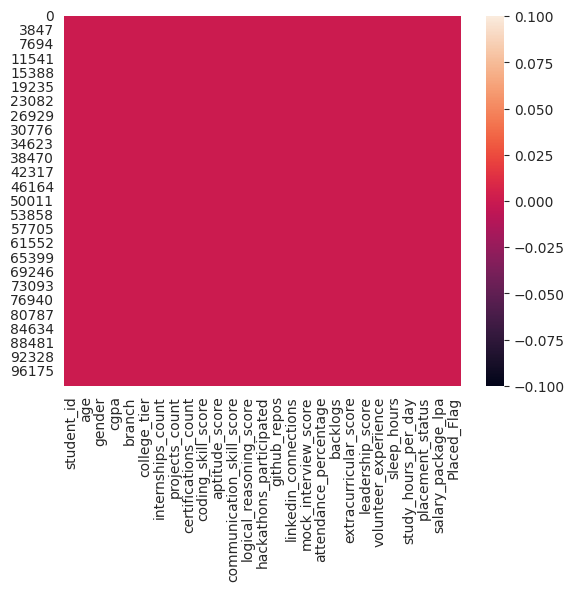

In [26]:
sns.heatmap(df.isnull())

Plotting histograms for numerical columns:


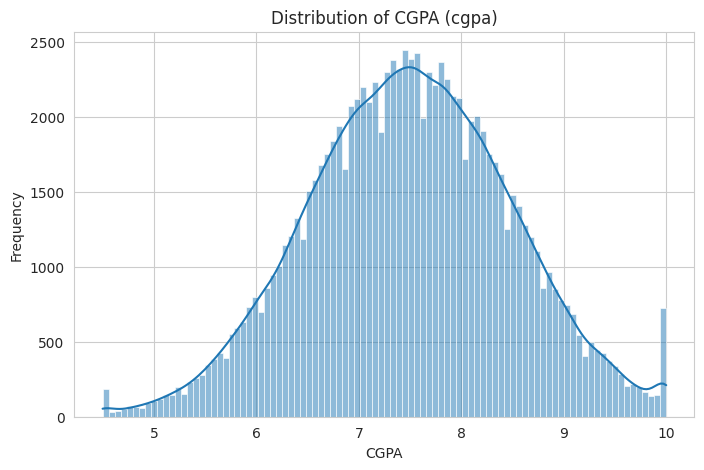

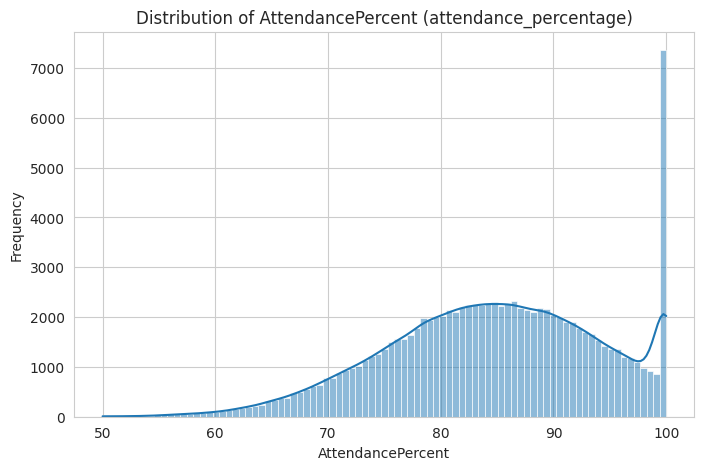

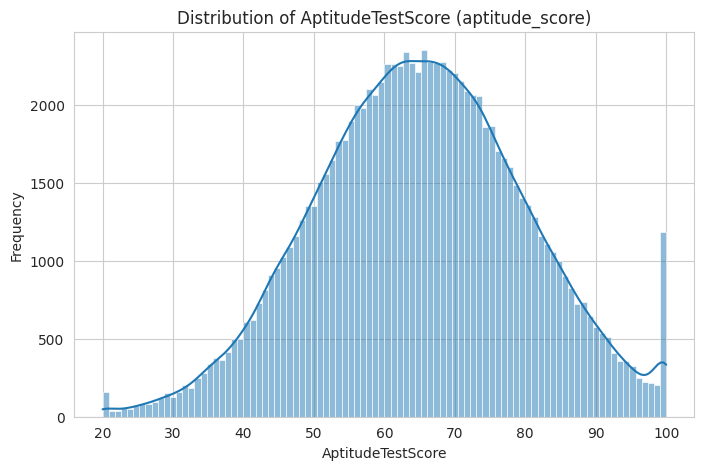

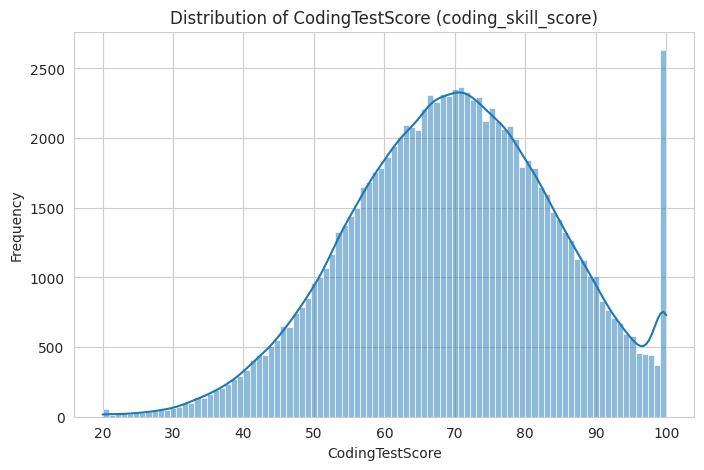

Column 'SoftSkillsRating' from `num_cols` does not have a direct corresponding column in the DataFrame. Skipping for now.


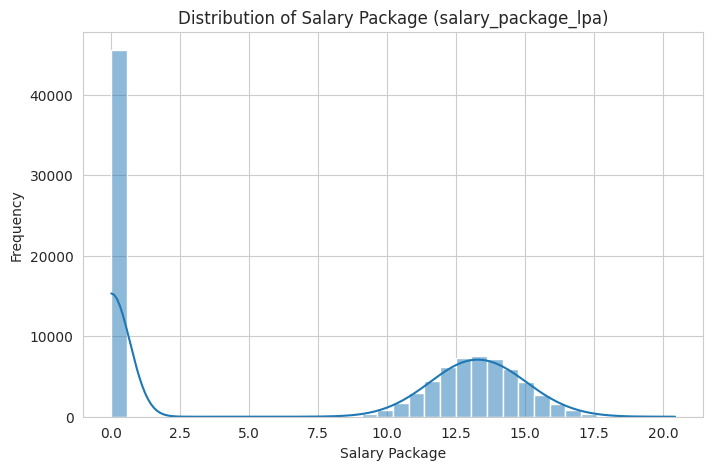

In [29]:
column_mapping = {
    'CGPA': 'cgpa',
    'AttendancePercent': 'attendance_percentage',
    'AptitudeTestScore': 'aptitude_score',
    'CodingTestScore': 'coding_skill_score',
    'Salary Package': 'salary_package_lpa'
}

print("Plotting histograms for numerical columns:")
for col_concept_name in num_cols:
    if col_concept_name in column_mapping:
        actual_df_column_name = column_mapping[col_concept_name]
        plt.figure(figsize=(8, 5))
        sns.histplot(df[actual_df_column_name], kde=True)
        plt.title(f'Distribution of {col_concept_name} ({actual_df_column_name})')
        plt.xlabel(col_concept_name)
        plt.ylabel('Frequency')
        plt.show()
    elif col_concept_name == 'SoftSkillsRating':
        print(f"Column '{col_concept_name}' from `num_cols` does not have a direct corresponding column in the DataFrame. Skipping for now.")
    else:
        print(f"Warning: Column '{col_concept_name}' from `num_cols` is not recognized and will be skipped.")

In [33]:
placement_rate=df.groupby('branch')['Placed_Flag'].mean()*100

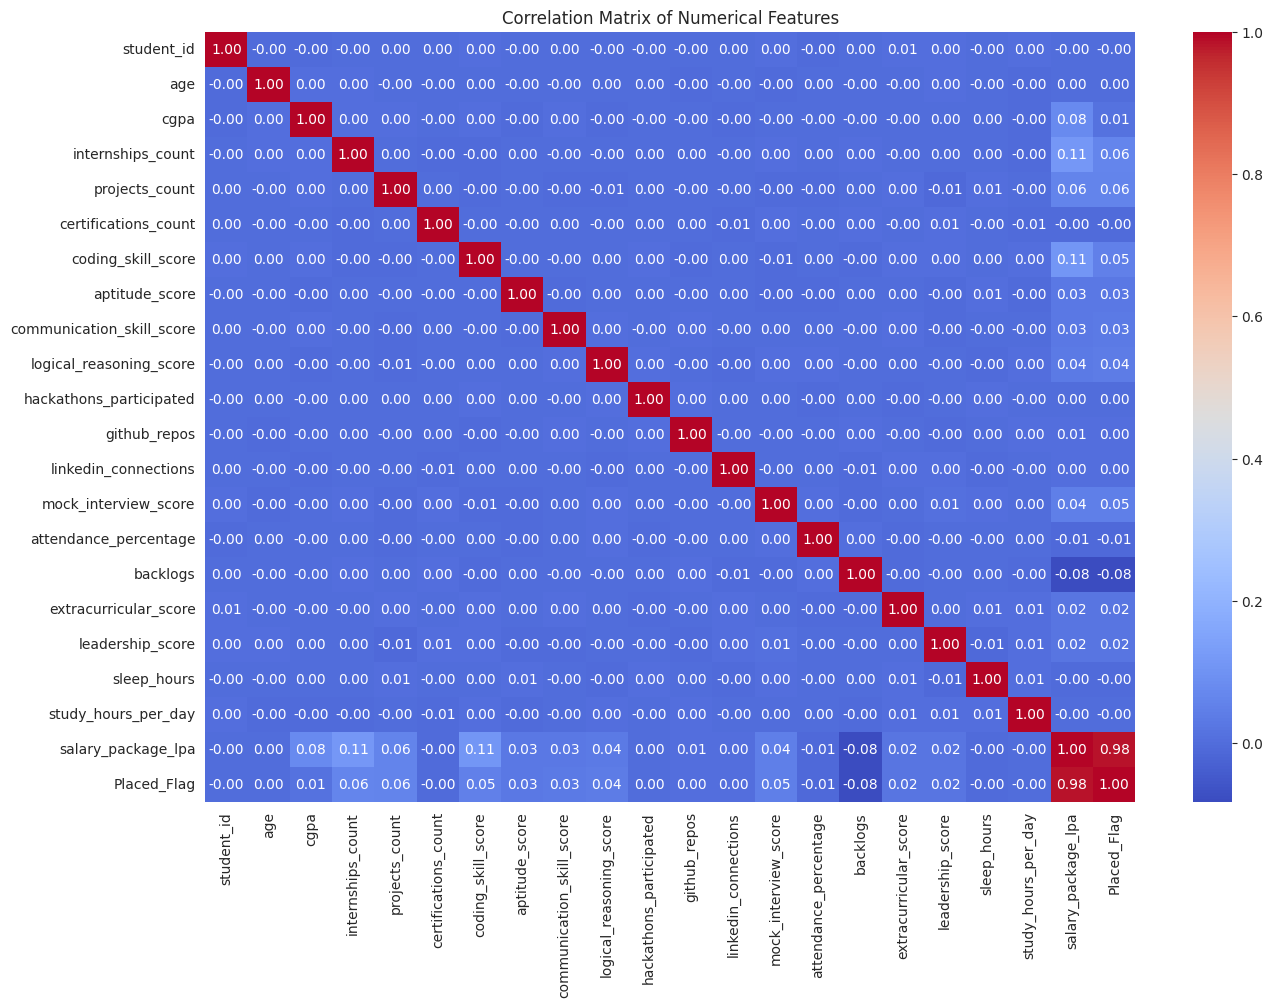

In [35]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

<Axes: >

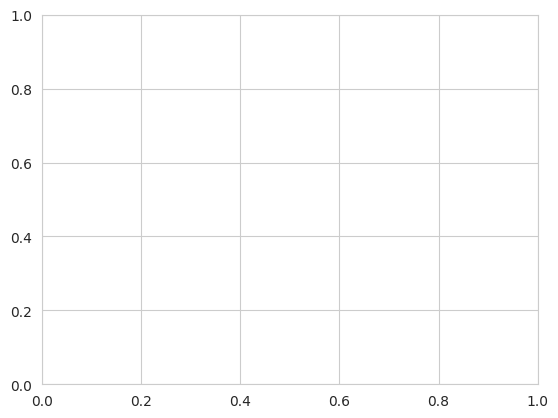

In [36]:
sns.boxplot()

In [39]:
from matplotlib.backends.backend_pdf import PdfPages

# Initialize PdfPages to save figures
pdf = PdfPages('output_plots.pdf')

# You would typically generate your figures here (e.g., from your plotting code)
# For example, if you had created a figure object named 'fig1' before this cell:
# pdf.savefig(fig1)

# As fig1 and fig2 are currently undefined, these lines will cause a NameError
# You need to ensure fig1 and fig2 (or whatever figure objects you want to save)
# are properly created before calling savefig on them.

# pdf.savefig(fig1) # This line will cause an error as fig1 is not defined
# pdf.savefig(fig2) # This line will cause an error as fig2 is not defined

# Close the PDF file to save all appended figures
pdf.close()